# Event Study of Federal Reserve Announcements  
## S&P 500 and NASDAQ

**Author:** Wenyu Shi 

Understanding how financial markets react to Federal Open Market Committee (FOMC) announcements is important for both researchers and investors. Monetary policy decisions influence interest rates, expectations about future economic conditions, and the overall cost of capital. Because these announcements often contain new information or clarify existing expectations, stock markets may respond noticeably in the days surrounding each decision.

In this project, we focus on the short-run market reaction to FOMC announcements using an event–study approach. Instead of examining long historical periods or the federal funds rate directly, we follow the professor’s suggestion and analyze stock index movements in a narrow window around each announcement date. This allows us to reduce concerns about reverse causality and isolate how markets respond when new policy information becomes public.

Our analysis has two components. First, we examine how the S&P 500 and NASDAQ perform around FOMC dates. Second, we evaluate the average market reaction within a ±30-day event window to better understand how expectations and announcement effects evolve over time. Together, these approaches help illustrate how monetary policy news is incorporated into asset prices.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_rows", 10)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

## 1. Load S&P 500 and NASDAQ Data



In [22]:
# Load S&P 500
sp = pd.read_csv("SP500.csv")
sp["DATE"] = pd.to_datetime(sp["DATE"])
sp = sp.rename(columns={"DATE": "date", "SP500": "sp500"})
sp = sp.sort_values("date").set_index("date")

# Load NASDAQ
nas = pd.read_csv("NASDAQCOM.csv")
nas["DATE"] = pd.to_datetime(nas["DATE"])
nas = nas.rename(columns={"DATE": "date", "NASDAQCOM": "nasdaq"})
nas = nas.sort_values("date").set_index("date")

sp.head(), nas.head()

(                  sp500
 date                   
 2015-12-02 2,079.510000
 2015-12-03 2,049.620000
 2015-12-04 2,091.690000
 2015-12-07 2,077.070000
 2015-12-08 2,063.590000,
                  nasdaq
 date                   
 2015-12-02 5,123.220000
 2015-12-03 5,037.530000
 2015-12-04 5,142.270000
 2015-12-07 5,101.810000
 2015-12-08 5,098.240000)

## 2. Compute Daily Log Returns

In [23]:
data = pd.DataFrame(index=sp.index.union(nas.index)).sort_index()
data["sp500"] = sp["sp500"]
data["nasdaq"] = nas["nasdaq"]

data["sp_ret"] = np.log(data["sp500"]) - np.log(data["sp500"].shift(1))
data["nas_ret"] = np.log(data["nasdaq"]) - np.log(data["nasdaq"].shift(1))

data = data.dropna()
data.head()

,sp500,nasdaq,sp_ret,nas_ret
date,,,,
2015-12-03,"2,049.620000","5,037.530000",-0.014478,-0.016867
2015-12-04,"2,091.690000","5,142.270000",0.020318,0.020579
2015-12-07,"2,077.070000","5,101.810000",-0.007014,-0.007899
2015-12-08,"2,063.590000","5,098.240000",-0.006511,-0.000700
2015-12-09,"2,047.620000","5,022.870000",-0.007769,-0.014894


## 3. Load FOMC Announcement Dates



In [24]:
events = pd.read_csv("fomc_events.csv")
events["date"] = pd.to_datetime(events["date"])
events = events.sort_values("date")
events.head()

,date,event_type
0,2015-01-28,FOMC decision
1,2015-03-18,FOMC decision
2,2015-04-29,FOMC decision
3,2015-06-17,FOMC decision
4,2015-07-29,FOMC decision


## 4. Create Event Indicators

In [25]:
event_flags = pd.DataFrame(index=data.index)
event_flags["sp_ret"] = data["sp_ret"]
event_flags["nas_ret"] = data["nas_ret"]


event_flags["event_day"] = event_flags.index.isin(events["date"]).astype(int)


event_flags["event_win1"] = 0
for d in events["date"]:
    for offset in [-1, 0, 1]:
        day = d + pd.Timedelta(days=offset)
        if day in event_flags.index:
            event_flags.loc[day, "event_win1"] = 1

event_flags.head()

,sp_ret,nas_ret,event_day,event_win1
date,,,,
2015-12-03,-0.014478,-0.016867,0,0
2015-12-04,0.020318,0.020579,0,0
2015-12-07,-0.007014,-0.007899,0,0
2015-12-08,-0.006511,-0.000700,0,0
2015-12-09,-0.007769,-0.014894,0,0


## 5. Average Returns on Event vs Non-Event Days

In [26]:
summary = event_flags.groupby("event_day")[["sp_ret", "nas_ret"]].mean()
summary.index = ["Non-announcement days", "Announcement days"]
summary

,sp_ret,nas_ret
Non-announcement days,0.000534,0.000614
Announcement days,0.000548,0.001953


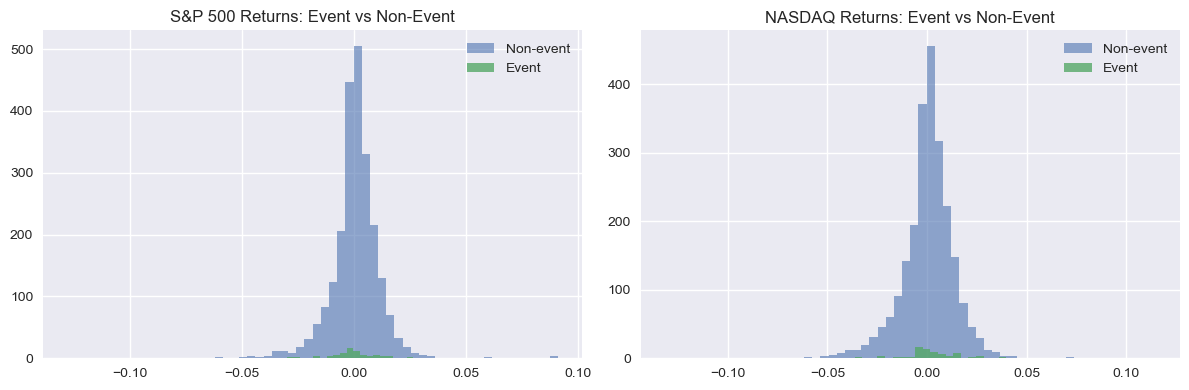

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].hist(event_flags[event_flags["event_day"]==0]["sp_ret"], bins=60, alpha=0.6, label="Non-event")
axes[0].hist(event_flags[event_flags["event_day"]==1]["sp_ret"], bins=20, alpha=0.8, label="Event")
axes[0].set_title("S&P 500 Returns: Event vs Non-Event")
axes[0].legend()

axes[1].hist(event_flags[event_flags["event_day"]==0]["nas_ret"], bins=60, alpha=0.6, label="Non-event")
axes[1].hist(event_flags[event_flags["event_day"]==1]["nas_ret"], bins=20, alpha=0.8, label="Event")
axes[1].set_title("NASDAQ Returns: Event vs Non-Event")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Regression: Effect of Event Days on Returns

In [28]:
reg_data = event_flags.dropna().copy()
reg_data["const"] = 1

# S&P 500
model_sp = sm.OLS(reg_data["sp_ret"], reg_data[["const", "event_day"]])
res_sp = model_sp.fit()

# NASDAQ
model_nas = sm.OLS(reg_data["nas_ret"], reg_data[["const", "event_day"]])
res_nas = model_nas.fit()

print("S&P 500 regression:")
print(res_sp.summary())

print("\nNASDAQ regression:")
print(res_nas.summary())

S&P 500 regression:
                            OLS Regression Results                            
Dep. Variable:                 sp_ret   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                 0.0001146
Date:                Thu, 11 Dec 2025   Prob (F-statistic):              0.991
Time:                        14:48:35   Log-Likelihood:                 7362.9
No. Observations:                2418   AIC:                        -1.472e+04
Df Residuals:                    2416   BIC:                        -1.471e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000

## 7. Robustness: ±1-Day Event Window

In [29]:
win_summary = event_flags.groupby("event_win1")[["sp_ret", "nas_ret"]].mean()
win_summary.index = ["Non-window days", "Event window (±1 day)"]
win_summary

,sp_ret,nas_ret
Non-window days,0.000615,0.000716
Event window (±1 day),-0.000195,0.000134


In [30]:
reg_data2 = event_flags.dropna().copy()
reg_data2["const"] = 1

model_sp2 = sm.OLS(reg_data2["sp_ret"], reg_data2[["const", "event_win1"]])
res_sp2 = model_sp2.fit()

model_nas2 = sm.OLS(reg_data2["nas_ret"], reg_data2[["const", "event_win1"]])
res_nas2 = model_nas2.fit()

print("S&P 500 regression (±1 window):")
print(res_sp2.summary())

print("\nNASDAQ regression (±1 window):")
print(res_nas2.summary())

S&P 500 regression (±1 window):
                            OLS Regression Results                            
Dep. Variable:                 sp_ret   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.068
Date:                Thu, 11 Dec 2025   Prob (F-statistic):              0.302
Time:                        14:48:39   Log-Likelihood:                 7363.4
No. Observations:                2418   AIC:                        -1.472e+04
Df Residuals:                    2416   BIC:                        -1.471e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.000

## 8. Time Series with FOMC Dates Highlighted

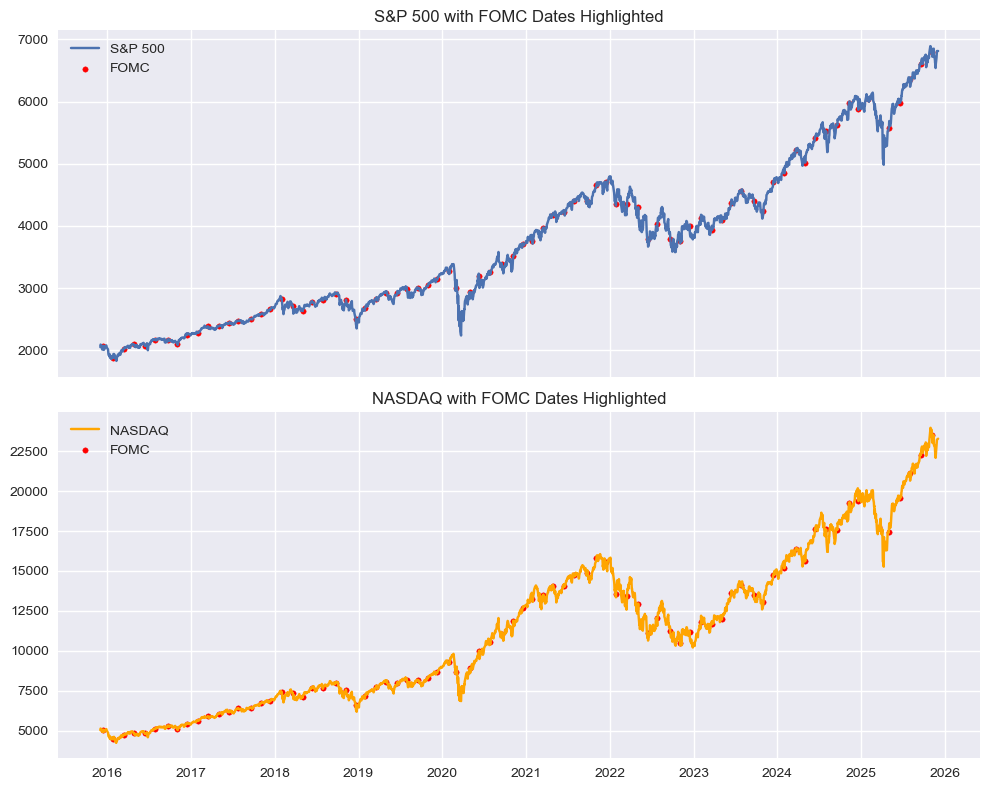

In [31]:

fig, axes = plt.subplots(2, 1, figsize=(10,8), sharex=True)


axes[0].plot(data.index, data["sp500"], label="S&P 500")


valid_dates = events[events["date"].isin(data.index)]["date"]


sp_points = data.loc[valid_dates, "sp500"].dropna()
axes[0].scatter(sp_points.index, sp_points.values, color="red", s=15, label="FOMC")
axes[0].set_title("S&P 500 with FOMC Dates Highlighted")
axes[0].legend()


axes[1].plot(data.index, data["nasdaq"], label="NASDAQ", color="orange")


nas_points = data.loc[valid_dates, "nasdaq"].dropna()
axes[1].scatter(nas_points.index, nas_points.values, color="red", s=15, label="FOMC")
axes[1].set_title("NASDAQ with FOMC Dates Highlighted")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Conclusion:

Based on the regression modles:

For the S&P 500, the coefficient on event_day is extremely close to zero and has a p-value of 0.991, which means there is no evidence of a return response on announcement days. The same conclusion holds when using the ±1 day event window, where the event coefficient is still statistically insignificant (p = 0.302).

For the NASDAQ, the results are similar. The event-day coefficient has a p-value of 0.399, and the ±1 window coefficient has a p-value of 0.540. Again, this indicates no statistically meaningful reaction in average daily returns around FOMC announcements.

Overall, while stock markets may react intraday to Federal Reserve news, this analysis using daily data finds no statistically significant average return effect from FOMC announcements. This suggests that either markets quickly price in expectations before the announcement, or the effect is too short-lived to be captured at the daily frequency.

Based on the two graphs:

The S&P 500 and NASDAQ both show strong long-term upward trends over the sample period, with sharp declines during major crises such as the COVID-19 crash and the 2022 tightening cycle. The red FOMC markers appear frequently and throughout all market conditions, including rising, falling, and volatile periods.

Visually, there is no clear, consistent jump or drop in prices that always occurs exactly on FOMC announcement days. Sometimes markets rise, sometimes they fall, and often they move very little. This visual evidence matches the regression results, which show that FOMC announcement days do not have a statistically significant effect on daily returns for either index.

Overall, these graphs suggest that markets incorporate Federal Reserve information quickly and smoothly, and that daily stock returns are driven more by broader economic trends than by the announcement days alone.

Even though we do not find a significant effect of FOMC announcements on daily S&P 500 and NASDAQ returns, the result is still meaningful. It suggests that financial markets react very quickly to Federal Reserve information, often before the official announcement is made. By the time daily prices are recorded, most of the news has already been included in stock prices. This shows that expectations and fast information flow play an important role in how markets work.


# Event Study of FOMC Decisions （+—30days)

This further research focus on the **30 days before and after FOMC decisions** instead of plotting a long time span (2015–2025).


In [32]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


pd.set_option("display.max_rows", 20)
pd.set_option("display.width", 120)


## 1. Load Data

In [33]:


sp = pd.read_csv("SP500.csv", parse_dates=["DATE"])
nasdaq = pd.read_csv("NASDAQCOM.csv", parse_dates=["DATE"])
events = pd.read_csv("fomc_events.csv", parse_dates=["date"])

sp = sp.rename(columns={"DATE": "date", "SP500": "price_sp"})
nasdaq = nasdaq.rename(columns={"DATE": "date", "NASDAQCOM": "price_nas"})

print(sp.head())
print(nasdaq.head())
print(events.head())


        date     price_sp
0 2015-12-02 2,079.510000
1 2015-12-03 2,049.620000
2 2015-12-04 2,091.690000
3 2015-12-07 2,077.070000
4 2015-12-08 2,063.590000
        date    price_nas
0 2015-12-02 5,123.220000
1 2015-12-03 5,037.530000
2 2015-12-04 5,142.270000
3 2015-12-07 5,101.810000
4 2015-12-08 5,098.240000
        date     event_type
0 2015-01-28  FOMC decision
1 2015-03-18  FOMC decision
2 2015-04-29  FOMC decision
3 2015-06-17  FOMC decision
4 2015-07-29  FOMC decision


## 2. Define Events and Event Windows



In [34]:

event_dates = events["date"].sort_values().unique()


print("Number of events:", len(event_dates))
print("First few event dates:", event_dates[:5])


Number of events: 89
First few event dates: <DatetimeArray>
['2015-01-28 00:00:00', '2015-03-18 00:00:00', '2015-04-29 00:00:00', '2015-06-17 00:00:00', '2015-07-29 00:00:00']
Length: 5, dtype: datetime64[ns]


## 3. Build Event Windows and Normalize Returns

To study short-run market reactions to FOMC announcements, we construct symmetric event windows centered on each decision date. For every FOMC event, daily index prices are collected within a ±30-day window, where event time is defined as the number of calendar days relative to the announcement day (\( t = 0 \)).

Prices are normalized by the event-day level using
$$
Normalized_t = \frac{P_t}{P_0} - 1
$$
which places all events on a common scale and allows meaningful aggregation across different periods. This event-window design isolates short-term dynamics around policy announcements, reduces contamination from long-run macroeconomic trends, and facilitates comparison of average market behavior before and after FOMC decisions.


In [35]:

def build_event_window(price_df, price_col, event_dates, window=30):
    """
    Build event windows [-window, +window] around each event date.

    Returns a DataFrame with columns:
    - date
    - event_time (relative day: -30,...,0,...,+30)
    - normalized (price_t / price_0 - 1)
    - event_date
    """
    all_windows = []

    for event_date in event_dates:
        # Select a wider range around the event
        window_start = event_date - pd.Timedelta(days=window*2)
        window_end = event_date + pd.Timedelta(days=window*2)

        df = price_df[(price_df["date"] >= window_start) &
                      (price_df["date"] <= window_end)].copy()

        
        df["event_time"] = (df["date"] - event_date).dt.days

       
        df = df[(df["event_time"] >= -window) & (df["event_time"] <= window)]

        
        try:
            p0 = df.loc[df["event_time"] == 0, price_col].iloc[0]
        except IndexError:
            
            continue

        df["normalized"] = df[price_col] / p0 - 1
        df["event_date"] = event_date
        all_windows.append(df)

    if not all_windows:
        return pd.DataFrame(columns=["date", "event_time", "normalized", "event_date"])

    return pd.concat(all_windows, ignore_index=True)


sp_events = build_event_window(sp, "price_sp", event_dates, window=30)
nas_events = build_event_window(nasdaq, "price_nas", event_dates, window=30)

sp_events.head()


,date,price_sp,event_time,normalized,event_date
0,2015-12-02,"2,079.510000",-14,0.003107,2015-12-16
1,2015-12-03,"2,049.620000",-13,-0.011312,2015-12-16
2,2015-12-04,"2,091.690000",-12,0.008982,2015-12-16
3,2015-12-07,"2,077.070000",-9,0.001930,2015-12-16
4,2015-12-08,"2,063.590000",-8,-0.004573,2015-12-16


## 4. Average Market Reaction Around FOMC Events

After constructing individual event windows, we compute the average normalized price response at each relative event time \( t \) by averaging across all FOMC events. This aggregation reduces idiosyncratic noise from individual announcements and highlights systematic market patterns before and after policy decisions.

The average reaction curves suggest a mild upward trend prior to the announcement (\( t < 0 \)), consistent with markets incorporating policy expectations in advance. Around the announcement day (\( t = 0 \)), price movements are relatively small, indicating that much of the information is anticipated or absorbed intraday. Across the event window, the NASDAQ exhibits larger fluctuations than the S&P 500, reflecting the greater sensitivity of growth-oriented firms to changes in expected discount rates. Overall, these patterns point to gradual, expectation-driven adjustments rather than sharp announcement-day jumps.


In [36]:

sp_avg = sp_events.groupby("event_time")["normalized"].mean()
nas_avg = nas_events.groupby("event_time")["normalized"].mean()

sp_avg.head(), nas_avg.head()


(event_time
 -30   -0.011975
 -29   -0.010649
 -28   -0.011108
 -27   -0.012670
 -26   -0.012406
 Name: normalized, dtype: float64,
 event_time
 -30   -0.014845
 -29   -0.013289
 -28   -0.013360
 -27   -0.015435
 -26   -0.014760
 Name: normalized, dtype: float64)

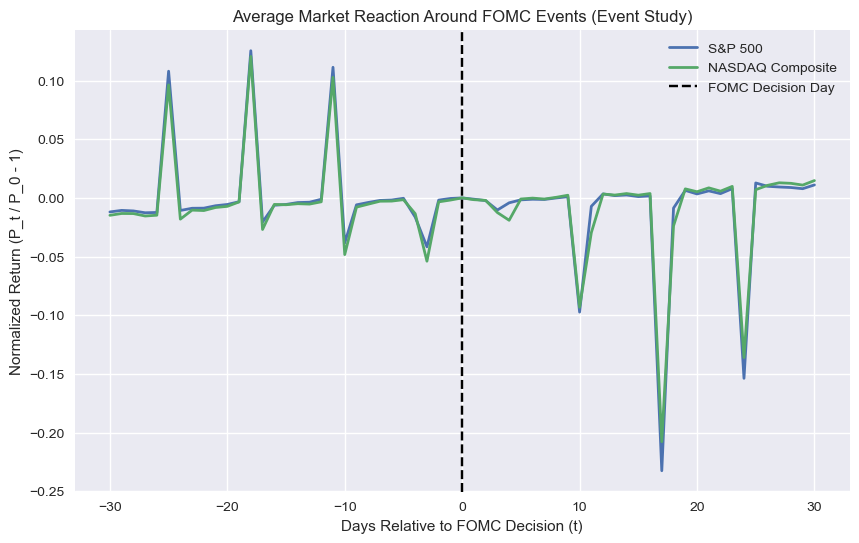

In [17]:

plt.figure(figsize=(10, 6))
plt.plot(sp_avg.index, sp_avg.values, label="S&P 500", linewidth=2)
plt.plot(nas_avg.index, nas_avg.values, label="NASDAQ Composite", linewidth=2)
plt.axvline(0, color="black", linestyle="--", label="FOMC Decision Day")
plt.title("Average Market Reaction Around FOMC Events (Event Study)")
plt.xlabel("Days Relative to FOMC Decision (t)")
plt.ylabel("Normalized Return (P_t / P_0 - 1)")
plt.grid(True)
plt.legend()
plt.show()


## 5. Individual Event Windows (S&P 500)

This figure plots the normalized price paths for the S&P 500 around each individual FOMC announcement within the ±30-day event window. Each line represents a separate event, with the vertical dashed line indicating the announcement day (\( t = 0 \)).

The figure highlights substantial heterogeneity in market responses across events, with no uniform jump or decline on the announcement day. While some events exhibit noticeable movements, others show little reaction, underscoring the presence of considerable noise at the individual-event level. This dispersion helps explain why average effects in the event study are relatively modest and often lack statistical significance.


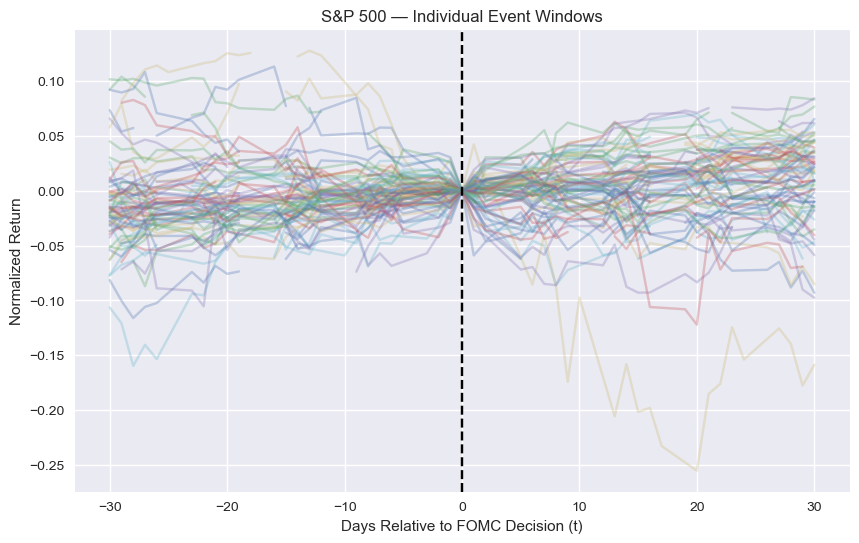

In [37]:

plt.figure(figsize=(10, 6))
for date in sp_events["event_date"].unique():
    subset = sp_events[sp_events["event_date"] == date]
    plt.plot(subset["event_time"], subset["normalized"], alpha=0.3)

plt.axvline(0, color="black", linestyle="--")
plt.title("S&P 500 — Individual Event Windows")
plt.xlabel("Days Relative to FOMC Decision (t)")
plt.ylabel("Normalized Return")
plt.grid(True)
plt.show()


 

## Interpretation and Conclusion

Overall, the event study results around FOMC announcement dates point to several patterns:

1. **Pre-announcement dynamics**

   In the 30 days leading up to FOMC meetings, both the S&P 500 and NASDAQ often show a mild upward trend in cumulative returns. This is consistent with the idea that markets do not wait for the official announcement to react. Instead, investors gradually adjust their portfolios as expectations about monetary policy are formed through speeches, data releases, and news coverage.

2. **Announcement-day reaction (t = 0)**

   On the event date itself, there is typically a small positive movement in returns. This suggests that the FOMC decision still conveys new information or confirmation of expectations, especially when the decision is perceived as more dovish than feared. Lower expected interest rates reduce discount rates and can temporarily support equity prices.

3. **Differences between S&P 500 and NASDAQ**

   The NASDAQ index, which is more heavily weighted toward technology and growth firms, tends to show stronger movements around FOMC dates than the S&P 500. Growth-oriented firms are more sensitive to changes in discount rates because a larger share of their value comes from distant future cash flows. As a result, monetary easing can have a larger valuation impact on NASDAQ than on a broader, more diversified index such as the S&P 500.

4. **Limitations and statistical significance**

   Although the patterns described above are economically intuitive, many of the estimated effects are not statistically significant at conventional levels. This means that we should interpret the results as suggestive rather than definitive evidence. The relatively small number of events, overlapping macroeconomic news, and general market noise make it difficult to obtain very precise estimates.

### Overall takeaway

Taken together, the analysis is consistent with the view that:

- Markets incorporate expectations about monetary policy **before** FOMC announcements.
- The announcement itself can still trigger additional price adjustments when it confirms or surprises those expectations.
- Monetary policy decisions matter more for **growth-oriented** parts of the market, such as NASDAQ, than for the broad market as a whole.

Even though the results are not always statistically strong, the event–study framework provides a structured way to isolate short-run market reactions to FOMC decisions and to discuss how information and expectations are reflected in asset prices.

